## **ДИСКУРС-АНАЛИЗ СОЛИДАРНОСТИ В ДОКУМЕНТАХ ДВИЖЕНИЯ НЕПРИСОЕДИНЕНИЯ**

In [5]:
import re
import warnings
import numpy as np
import pandas as pd

import spacy
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer

import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

In [6]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10
pd.set_option("display.max_colwidth", 250)


## Загрузка корпуса

In [7]:
NAM = "nam_corpus.csv"
df1 = pd.read_csv(NAM)

#берём базовые поля корпуса
required_columns = ["source", "title", "text", "year", "location", "doc_type", "summit_number"]
for col in required_columns:
    if col not in df1.columns:
        df1[col] = pd.NA
df1 = df1[required_columns].copy()

#год из исходной колонки year
year_from_col = pd.to_numeric(df1["year"], errors="coerce")

#год по номеру саммита (если есть пара summit_number -> year в данных)
summit_year_map = (df1.loc[df1["summit_number"].notna() & df1["year"].notna(), ["summit_number", "year"]].drop_duplicates("summit_number").set_index("summit_number")["year"].astype(float).to_dict())
year_from_summit = pd.to_numeric(df1["summit_number"].map(summit_year_map), errors="coerce")

#подбираем пустые ячейки добираем из заголовка 
header_text = (df1["source"].fillna("").astype(str).str.cat(df1["title"].fillna("").astype(str), sep=" ").str.cat(df1["text"].fillna("").astype(str).str.slice(0, 600), sep=" "))
year_from_header = pd.to_numeric(header_text.str.extract(r"(19\d{2}|20\d{2})")[0], errors="coerce")

#итоговый год
year = year_from_col.fillna(year_from_summit).fillna(year_from_header)
year_source = np.select(
    [year_from_col.notna(), year_from_col.isna() & year_from_summit.notna(), year_from_col.isna() & year_from_summit.isna() & year_from_header.notna()],
    ["year_column", "summit_number", "header_text"],
    default="missing",
)

#собираем бд
df = pd.DataFrame({
    "year": year,
    "year_source": year_source,
    "title": df1["title"].fillna("").astype(str).str.strip(),
    "text": df1["text"].fillna("").astype(str).str.strip(),
    "source": df1["source"].fillna("").astype(str).str.strip(),
    "location": df1["location"].fillna("").astype(str).str.strip(),
    "doc_type": df1["doc_type"].fillna("").astype(str).str.strip(),
})

print("Количество строк - ", df.shape)
print("Строк с распознанным годом - ", int(df["year"].notna().sum()))
print("Строк без года - ", int(df["year"].isna().sum()))
print("Распределение по годам")
print(df["year"].dropna().astype(int).value_counts().sort_index())

Количество строк -  (56, 7)
Строк с распознанным годом -  44
Строк без года -  12
Распределение по годам
year
1961    2
1964    2
1970    3
1973    2
1976    2
1979    2
1983    2
1986    2
1989    2
1992    2
1995    2
1996    1
1998    2
2003    2
2006    3
2009    2
2011    3
2012    1
2016    2
2018    1
2019    2
2024    2
Name: count, dtype: int64


In [8]:
primt

,year,year_source,title,text,source,location,doc_type
0,2024.0,header_text,19th Summit Summary,"The Non-Aligned Movement (NAM)\nDatabase\nThematic Summary of the 19th Heads of State Summit of the Non-Aligned Movement,\nKampala, the Republic of Uganda (2024)\nDisarmament\n(Final Document, Para 279) The Heads of State and Government\nexpresse...",19th_Summit_Summary.pdf,,summary
1,2019.0,header_text,18th Summit Baku Declaration,"Original: English\nNAM 2019/CoB/Doc.11\n18th Summit of Heads of State and\nGovernment of the Non-Aligned Movement\nBaku, Republic of Azerbaijan\n25-26 October 2019\nBAKU DECLARATION\nof the 18th Summit of Heads of State and Government of the Non-...",18th_Summit_Baku_Declaration.pdf,Baku,declaration
2,2018.0,year_column,18th Ministerial Conference Final Document 2018,"NAM 2018/CoB/Doc.1\nOriginal: English\n18th Mid-Term Ministerial Meeting of the\nNon-Aligned Movement (NAM)\nBaku, Republic of Azerbaijan\n03-06 April 2018\nFINAL DOCUMENT\nBaku, Republic of Azerbaijan\n05-06 April 2018\nNAM 2018/CoB/Doc.1\nFINAL...",18th_Ministerial_Conference_Final_Document_2018.pdf,,ministerial
3,2019.0,year_column,18th Heads of State Final Document 2019,"Original: English\nNAM 2019/CoB/Doc.1\n18th Summit of Heads of State and Government of the Non-\nAligned Movement\nBaku, the Republic of Azerbaijan\n25 - 26 October 2019\nFINAL DOCUMENT\nBaku, Azerbaijan\n25-26 October 2019\nOriginal: English\nNA...",18th_Heads_of_State_Final_Document_2019.pdf,,final_document
4,2016.0,header_text,FINAL UPDATED 17th Summit Summary,"Thematic Summary of the 17th Heads of State Summit of the Non-Aligned Movement,\nMargarita, Venezuela (2016)\nDisarmament\n(Final Document, Para 176) The Heads of State or Government\nreaffirmed the importance of the Conference on Disarmament (CD...",FINAL_UPDATED_17th_Summit_Summary.pdf,,summary
5,2011.0,year_column,16th Ministerial Conference Final Document 2011,NAM 2011/Doc.1/Rev.1\nOriginal: English\nXVI Ministerial Conference and\nCommemorative Meeting\nof the Non-Aligned Movement\nBali – Indonesia\n23 – 27 May 2011\nFinal Document\n1\nNAM 2011/Doc.1/Rev.1\nOriginal: English\nFINAL DOCUMENT\nTABLE OF ...,16th_Ministerial_Conference_Final_Document_2011.pdf,,ministerial
6,2011.0,year_column,16th Ministerial Conference Bali Commemorative Declaration 2011,NAM 2011/Doc.7/Rev.1\nOriginal: Englis h\nXVI Ministerial Conference and\nCommemorative Meeting\nof the Non-Aligned Movement\nBali – Indonesia\n23 – 27 May 2011\nBALI COMMEMORATIVE DECLARATION\nON THE 50TH ANNIVERSARY OF THE ESTABLISHMENT OF\nTHE...,16th_Ministerial_Conference_Bali_Commemorative_Declaration_2011.pdf,,ministerial
7,2011.0,header_text,FINAL UPDATED 16th Summit Summary,"Thematic Summary of the 16th Heads of State Summit of the Non-Aligned Movement,\nBali, Indonesia (2011)\nDisarmament\n(Final Document, Para 142) The Ministers reaffirmed the importance\nof the Conference on Disarmament (CD) as the sole multilater...",FINAL_UPDATED_16th_Summit_Summary.pdf,,summary
8,2009.0,header_text,15Summit-Final- Compiled,"15th Summit Conference of Heads of State or\nGovernment of the Non-Aligned Movement\nSharm el-Sheikh, Egypt\n11 – 16 July 2009\nDOCUMENT:\n(Please click the following links)\nFinal Document – Chapter I: Global Issues – Disarmament and\nInternatio...",15Summit-Final-_Compiled.pdf,,final_document
9,2009.0,header_text,FINAL UPDATED 15th Summit Summary,"Thematic Summary of the 15th Heads of State Summit of the Non-Aligned Movement,\nSharm El Sheikh, Egypt (2009)\nDisarmament\n(Final Document, Para 112) The Heads of State and Government\nreaffirmed the importance of the Conference on Disarmament ...",FINAL_UPDATED_15th_Summit_Summary.pdf,,summary


## Очистка и нормализация текста для подсчета устойчивых единиц

In [26]:
clean = {
    "min_text_len": 120,
    "min_df": 2,
    "ngram_range": (2, 3),
    "analysis_exclude_terms": [
        "nam", "non", "aligned", "movement", "summit", "conference", "meeting",
        "state", "states", "member", "members", "country", "countries",
        "final", "document", "summary", "declaration",
        "government", "heads", "ministers", "minister", "include", "regard",
        "express", "welcome", "effort", "need", "use", "general", "assembly",
        "resolution", "international", "united", "nations", "implementation",
    ],
    "artifact_terms": [
        "nthe", "nthat", "nand", "nfor", "nfrom", "nwith", "nthis",
        "nbsp", "amp", "quot", "http", "https", "www", "com",
        "para", "original", "english", "inter", "alia", "assembl",
    ],
    "index_weights": {
        "norms_freq_z": 0.25,
        "cooperation_freq_z": 0.25,
        "reform_freq_z": 0.25,
        "development_freq_z": 0.25,
    },
}


def basic_clean(text: str) -> str:
    text = str(text)
    text = text.replace("\n", " ").replace("\t", " ").replace("\r", " ")
    text = text.replace("/n", " ").replace("&nbsp;", " ").replace("&amp;", " and ")
    text = text.replace("\xa0", " ")
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def title_fingerprint(text: str) -> str:
    return re.sub(r"\W+", "", str(text).lower())[:5000]


def text_fingerprint(text: str) -> str:
    return re.sub(r"\W+", "", str(text).lower())[:10000]


before = len(df)
df["text_clean"] = df["text"].apply(basic_clean)
df["title_clean"] = df["title"].apply(basic_clean)
df["title_fp"] = df["title_clean"].apply(title_fingerprint)
df["text_fp"] = df["text_clean"].apply(text_fingerprint)

print("Удалено при очистке:", before - len(df))
print("Размер корпуса после очистки:", df.shape)

Удалено при очистке: 0
Размер корпуса после очистки: (56, 11)


In [27]:
nlp_en = spacy.load("en_core_web_sm", disable=["parser", "ner"])
nlp_en.max_length = int(max(df["text_clean"].str.len().max(), 1_000_000) + 1000)
artifact_terms = set(clean.get("artifact_terms", []))


def lemmatize_en(text: str):
    doc = nlp_en(str(text))
    tokens = []
    for tok in doc:
        if tok.is_punct or tok.is_space:
            continue
        lemma = tok.lemma_.strip().lower()
        if not lemma:
            continue
        if not re.fullmatch(r"[a-z]{3,}", lemma):
            continue
        if lemma in artifact_terms:
            continue
        tokens.append(lemma)
    return tokens


df["lemmas"] = df["text_clean"].apply(lemmatize_en)
df["lemma_text"] = df["lemmas"].apply(" ".join)
df["token_count"] = df["lemmas"].str.len()

print(df[["token_count"]].describe())

         token_count
count      56.000000
mean    22564.482143
std     31638.252013
min       880.000000
25%      3756.000000
50%      6146.000000
75%     34353.750000
max    140533.000000


## Прежде чем считать индексы солидарности, смотрим, какая лексика реально доминирует в корпусе

In [28]:
stop_words = set(ENGLISH_STOP_WORDS)
analysis_exclude_terms = set(clean.get("analysis_exclude_terms", []))
analysis_exclude_terms.update(clean.get("artifact_terms", []))

# Дополнительный фильтр канцелярских слов
analysis_terms = {
    "reaffirm", "reiterate", "noted", "noting", "calls", "calling", "note",
    "emphasize", "emphasized", "importance", "support", "peace", "ensure",
    "issue", "promote", "stress",
}
analysis_exclude_terms.update(analysis_terms)

# 1) Частотность отдельных лемм
word_vectorizer = CountVectorizer(
    min_df=clean["min_df"],
    max_df=0.9,
    stop_words=list(stop_words),
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
)
word_matrix = word_vectorizer.fit_transform(df["lemma_text"])
word_list = word_vectorizer.get_feature_names_out()
word_counts = word_matrix.sum(axis=0).A1

df_word_freq = (
    pd.DataFrame({"term": word_list, "freq": word_counts})
    .sort_values("freq", ascending=False)
    .reset_index(drop=True)
)

df_word_freq = df_word_freq[
    (~df_word_freq["term"].isin(stop_words))
    & (~df_word_freq["term"].isin(analysis_exclude_terms))
    & (df_word_freq["term"].str.len() > 2)
].reset_index(drop=True)

# 2) Частотность 2-3 грамм
vectorizer_ng = CountVectorizer(
    ngram_range=clean["ngram_range"],
    min_df=clean["min_df"],
    max_df=0.9,
    stop_words=sorted(stop_words),
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
)
X_ng = vectorizer_ng.fit_transform(df["lemma_text"])
terms_ng = vectorizer_ng.get_feature_names_out()
freq_ng = X_ng.sum(axis=0).A1

df_freq_exp = (
    pd.DataFrame({"exp": terms_ng, "freq": freq_ng})
    .sort_values("freq", ascending=False)
    .reset_index(drop=True)
)

def has_bad_token(phrase: str) -> bool:
    return any(t in stop_words or t in analysis_exclude_terms for t in phrase.split())

df_freq_exp = df_freq_exp[
    (~df_freq_exp["exp"].apply(has_bad_token))
    & (~df_freq_exp["exp"].str.contains(r"\bpara\b|\boriginal\b|\benglish\b", regex=True))
].reset_index(drop=True)

print("Леммы")
print(df_word_freq.head(30))
print("Частотность выражений")
print(df_freq_exp.head(30))

Леммы
           term  freq
0        weapon  4702
1         right  3804
2   cooperation  3217
3         human  3032
4       council  2868
5        people  2720
6         south  2626
7      national  2188
8           law  2130
9        treaty  2043
10         role  2043
11     regional  2020
12   strengthen  1943
13        adopt  1930
14       global  1926
15      process  1831
16     relevant  1818
17      charter  1804
18   commitment  1792
19       review  1766
20      context  1766
21   particular  1765
22         urge  1740
23        level  1734
24  sustainable  1693
25   accordance  1655
26    community  1654
27   convention  1633
28      provide  1601
29    programme  1599
Частотность выражений
                        exp  freq
0            nuclear weapon  3042
1          security council  1786
2               human right  1517
3   sustainable development  1219
4       nuclear disarmament  1037
5           economic social   855
6               middle east   764
7              hum

In [29]:
df_word_freq.to_csv("nam_lemms_frequency.csv", index=False)
df_freq_exp.to_csv("nam_expression_frequency.csv", index=False)

## Теперь формируем 4 измерения солидарности 

In [30]:
norms_solidarity = {
    'solidarity', 'justice', 'equity', 'fairness', 'equality',
    'inclusive', 'inclusiveness', 'inclusion',
    'rights', 'human rights', 'fundamental rights', 'social rights',
    'dignity', 'human dignity',
    'responsibility', 'responsibilities', 'shared', 'common',
    'collective', 'mutual', 'respect', 'mutual respect',
    'rule of law', 'international law', 'international rule of law',
    'sovereign equality', 'sovereign rights',
    'common but differentiated responsibilities',
    'multipolar', 'multilateralism', 'multilateral',
    'inclusive growth', 'shared prosperity', 'shared responsibility',
    'mutual benefit', 'mutually beneficial', 'win win',
    'non discrimination', 'non-discrimination',
    'fair representation', 'equitable representation',
    'global justice', 'social justice',
    'peaceful coexistence', 'peaceful co-existence',
    'mutual understanding', 'mutual trust',
    'predictability', 'stability', 'balanced',
}

cooperation_solidarity = {
    'cooperation', 'cooperate', 'cooperative',
    'coordination', 'coordinate', 'joint',
    'partnership', 'partnerships', 'strategic partnership',
    'mechanism', 'mechanisms', 'framework', 'working group',
    'task force', 'contact group',
    'common position', 'common stand',
    'collective action', 'pool resources',
    'institutional collaboration', 'institutional cooperation',
    'consensus', 'exchange', 'exchange of views',
    'capacity building', 'joint capacity building',
    'brics cooperation', 'cooperation among', 'cooperation between',
    'joint statement', 'joint declaration', 'joint communique',
    'joint initiative', 'joint programme', 'joint program',
    'joint project', 'joint work', 'joint efforts',
    'coordinated measures', 'coordinated action',
    'information sharing', 'experience sharing',
    'peer learning', 'best practices',
    'intergovernmental cooperation',
    'people to people exchanges', 'people-to-people exchanges',
    'dialogue', 'political dialogue', 'regular dialogue',
}

reform_solidarity = {
    'unilateral', 'unilateral measures', 'unilateral actions',
    'sanctions', 'coercive', 'coercion',
    'hegemonic', 'hegemony',
    'domination', 'dominance',
    'neo colonial', 'neocolonial', 'neo-colonial',
    'reform', 'reforms', 'reforming',
    'global governance', 'reform of global governance',
    'security council reform', 'reform of the security council',
    'reform of the united nations', 'un reform',
    'multilateral trading system',
    'underrepresentation', 'under-representation',
    'non interference', 'non-interference',
    'non intervention', 'non-intervention',
    'unjust', 'unfair', 'imbalanced', 'asymmetric',
    'double standards',
    'outdated structures', 'outdated institutions',
    'institutional reform', 'systemic reform',
    'democratisation of international relations',
    'democratization of international relations',
    'inclusive multilateralism',
    'greater voice', 'greater representation',
}

development_solidarity = {
    'development', 'sustainable development', 'sustainable growth',
    'infrastructure', 'infrastructure development',
    'finance', 'financing', 'development finance',
    'development bank', 'new development bank', 'ndb',
    'investment', 'investments', 'investment flows',
    'economic growth', 'inclusive growth',
    'technology transfer', 'transfer of technology',
    'capacity building', 'institutional capacity',
    'industrialisation', 'industrialization',
    'poverty', 'poverty eradication', 'poverty reduction',
    'food security', 'energy security',
    'health', 'public health', 'global health',
    'education', 'access to education',
    'climate finance', 'climate-resilient development',
    'digital', 'digitalisation', 'digitalization', 'digital economy',
    'connectivity', 'digital connectivity',
    'sdgs', 'sustainable development goals',
    'developing countries', 'global south',
    'social development', 'human development',
    'inclusive development', 'balanced development',
    'green development', 'low carbon development',
    'economic diversification', 'structural transformation',
}

base_terms = {
    'norms': norms_solidarity,
    'cooperation': cooperation_solidarity,
    'reform': reform_solidarity,
    'development': development_solidarity,
}

dictionary = {dim: {tuple(term.split()) for term in terms} for dim, terms in base_terms.items()}


def count_lexicon_items(lemmas, lexicon_items):
    total_count = 0
    ngram_cache = {}
    for item in lexicon_items:
        n = len(item)
        if n == 1:
            total_count += lemmas.count(item[0])
            continue
        if n not in ngram_cache:
            if len(lemmas) < n:
                ngram_cache[n] = []
            else:
                ngram_cache[n] = [tuple(lemmas[i:i+n]) for i in range(len(lemmas) - n + 1)]
        total_count += sum(1 for gram in ngram_cache[n] if gram == item)
    return total_count

In [31]:
def count_lexicon_items(lemmas, lexicon_items):
    total_count = 0
    ngram_cache = {}
    for item in lexicon_items:
        n = len(item)
        if n == 1:
            total_count += lemmas.count(item[0])
            continue
        if n not in ngram_cache:
            if len(lemmas) < n:
                ngram_cache[n] = []
            else:
                ngram_cache[n] = [tuple(lemmas[i:i+n]) for i in range(len(lemmas) - n + 1)]
        total_count += sum(1 for gram in ngram_cache[n] if gram == item)
    return total_count


def compute_lexicon_indices_row(row: pd.Series) -> pd.Series:
    lemmas = row["lemmas"]
    token_count = len(lemmas) if len(lemmas) > 0 else 1
    raw_counts = {}
    rel_freqs = {}
    for dim_name, lexicon_items in dictionary.items():
        raw_value = count_lexicon_items(lemmas, lexicon_items)
        raw_counts[f"{dim_name}_raw"] = raw_value
        rel_freqs[f"{dim_name}_freq"] = raw_value / token_count
    return pd.Series({**raw_counts, **rel_freqs, "tokens": token_count})


lex_df = df.apply(compute_lexicon_indices_row, axis=1)
df = pd.concat([df, lex_df], axis=1)

# Если ячейка запускается повторно, убираем дублирующиеся имена колонок.
df = df.loc[:, ~df.columns.duplicated()].copy()

freq_cols = ["norms_freq", "cooperation_freq", "reform_freq", "development_freq"]
for col in freq_cols:
    series = df[col]
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]

    mean_value = float(series.mean())
    std_value = float(series.std(ddof=0))
    if std_value == 0 or np.isnan(std_value):
        std_value = 1.0
    df[col + "_z"] = (series - mean_value) / std_value

index_weights = clean["index_weights"]
df["solidarity_index"] = sum(df[col] * w for col, w in index_weights.items())

print(df[["year", "norms_freq", "cooperation_freq", "reform_freq", "development_freq", "solidarity_index"]].head())

     year  norms_freq  cooperation_freq  reform_freq  development_freq  \
0  2024.0    0.005607          0.005926     0.000239          0.003853   
1  2019.0    0.020267          0.013819     0.005527          0.013819   
2  2018.0    0.011611          0.010891     0.001960          0.016044   
3  2019.0    0.011189          0.010539     0.001841          0.015488   
4  2016.0    0.005084          0.005005     0.000196          0.003402   

   solidarity_index  
0         -0.466041  
1          2.627348  
2          1.223974  
3          1.121143  
4         -0.585447  


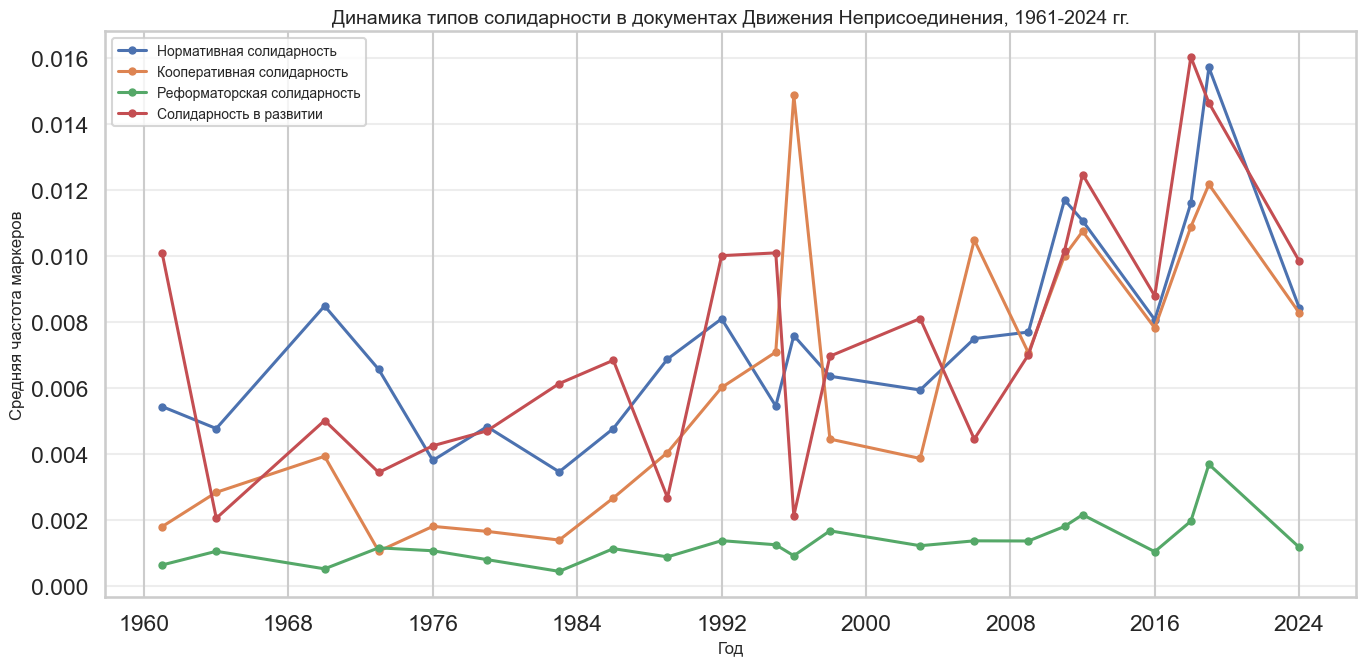

In [32]:
plot_df = df[df["year"].notna()].copy()
plot_df["year"] = plot_df["year"].astype(int)

by_year = (
    plot_df.groupby("year")[["norms_freq", "cooperation_freq", "reform_freq", "development_freq"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

fig, ax = plt.subplots(figsize=(14, 7))
for col, label in [
    ("norms_freq", "Нормативная солидарность"),
    ("cooperation_freq", "Кооперативная солидарность"),
    ("reform_freq", "Реформаторская солидарность"),
    ("development_freq", "Солидарность в развитии"),
]:
    ax.plot(
        by_year["year"],
        by_year[col],
        marker="o",
        linewidth=2.2,
        markersize=5,
        label=label,
    )

ax.set_title("Динамика типов солидарности в документах Движения Неприсоединения, 1961-2024 гг.")
ax.set_xlabel("Год")
ax.set_ylabel("Средняя частота маркеров")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.35)
ax.legend(frameon=True, loc="upper left")
plt.tight_layout()
plt.show()

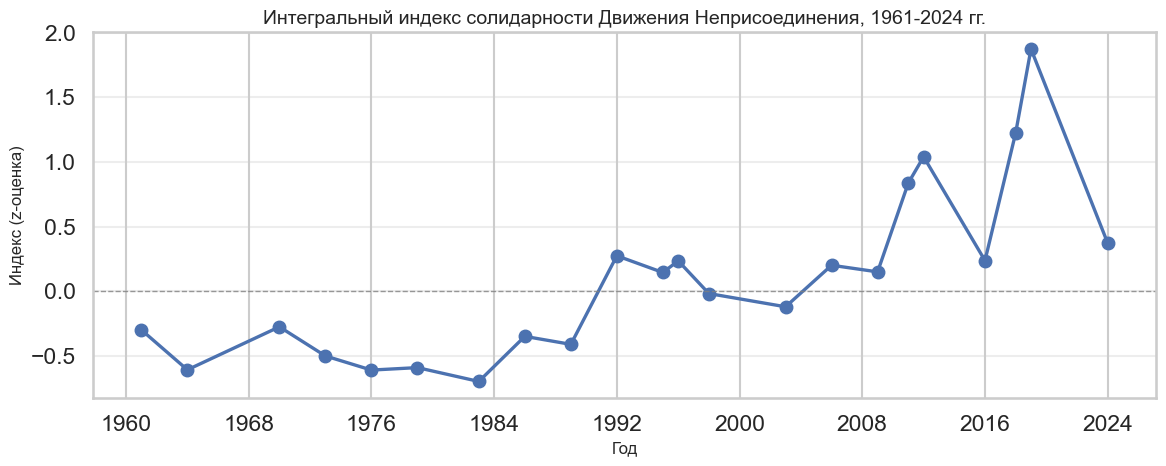

In [33]:
by_year_index = (plot_df.groupby("year", as_index=False)["solidarity_index"].mean().sort_values("year"))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    by_year_index["year"],
    by_year_index["solidarity_index"],
    marker="o",
    linewidth=2.4,
)
ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.8)
ax.set_title("Интегральный индекс солидарности Движения Неприсоединения, 1961-2024 гг.")
ax.set_xlabel("Год")
ax.set_ylabel("Индекс (z-оценка)")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

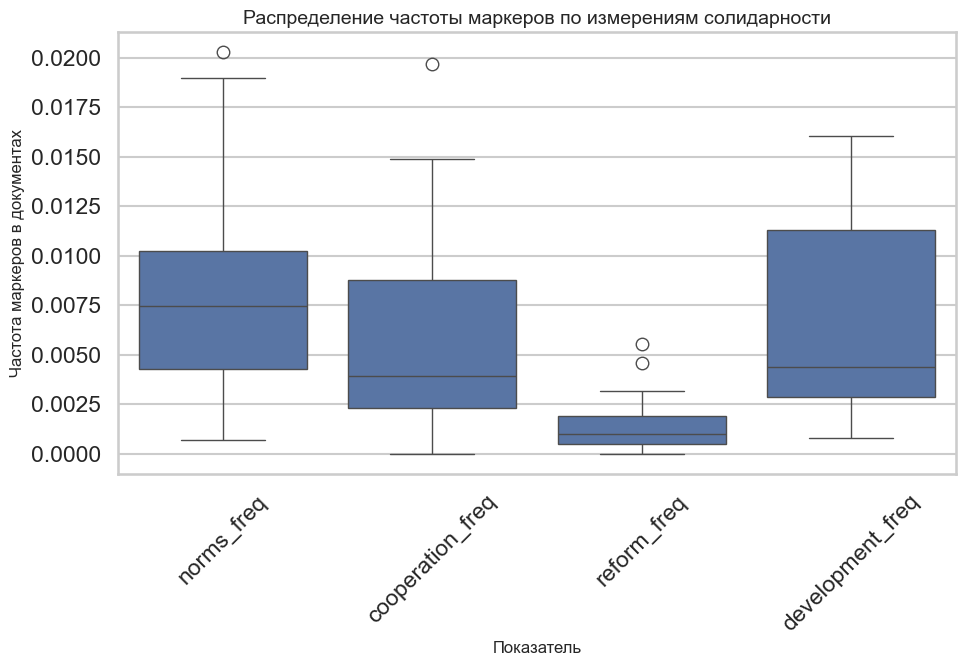

In [34]:
melted = df.melt(
    value_vars=["norms_freq", "cooperation_freq", "reform_freq", "development_freq"],
    var_name="dimension",
    value_name="freq",
)

plt.figure(figsize=(10, 7))

sns.boxplot(data=melted, x="dimension", y="freq")

plt.xticks(rotation=45)
plt.title("Распределение частоты маркеров по измерениям солидарности")
plt.xlabel("Показатель")
plt.ylabel("Частота маркеров в документах")
plt.tight_layout()
plt.show()

## Интерпретация графика четырех измерений

График показывает, какие компоненты солидарности в NAM оказываются доминирующими в разные годы, и за счет каких измерений меняется общий профиль дискурса.


## Интерпретация интегрального индекса по годам

`solidarity_index` позволяет увидеть общий уровень солидарной риторики относительно среднего по корпусу.

- значения выше 0 — риторика солидарности выражена сильнее среднего;
- значения ниже 0 — слабее среднего;
- около 0 — близко к типичному уровню корпуса.


## Интерпретация boxplot

Boxplot показывает не только средний уровень, но и разброс каждого измерения: насколько равномерно соответствующая риторика распределена по документам NAM.


       partner_diversity  issue_diversity
count          56.000000        56.000000
mean            1.267857         3.125000
std             1.519462         3.917618
min             0.000000         0.000000
25%             0.000000         1.000000
50%             1.000000         1.000000
75%             2.000000         4.000000
max             6.000000        14.000000


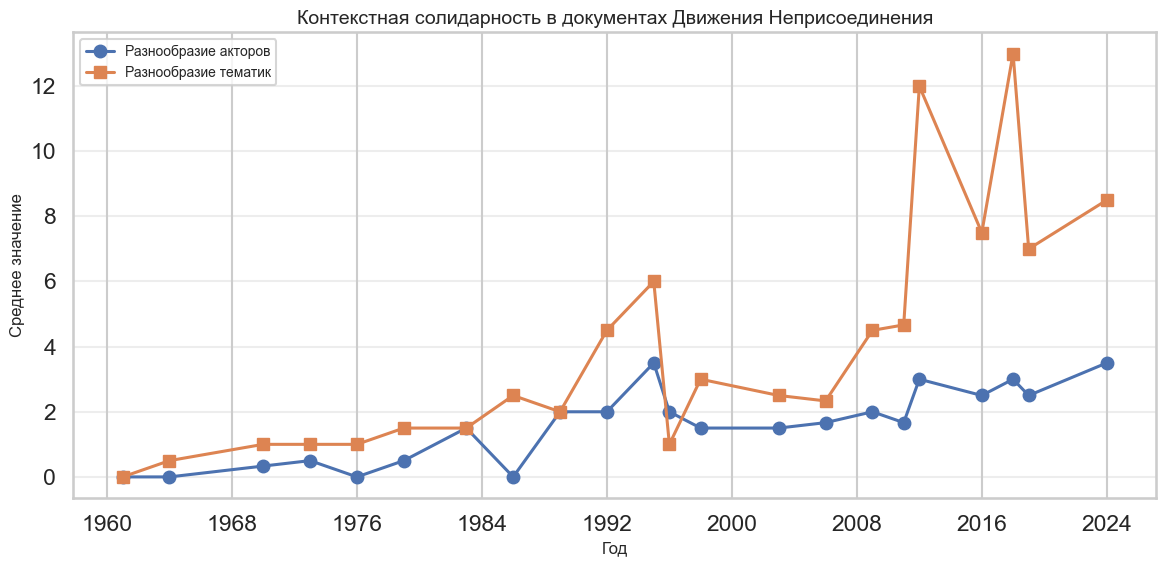

In [35]:
solidarity_markers = {
     "solidarity",
    "cooperation",
    "cooperate",
    "partnership",
    "joint",
    "consensus",
    "collective",
    "mutual",
    "coordination",
}

solidarity_actors = {
    "nam", "non aligned movement", "global south", "developing countries",
    "united nations", "security council", "wto", "imf", "world bank", "g77",
}

solidarity_issues = {
    "trade", "investment", "finance", "debt", "climate", "security",
    "sanctions", "health", "education", "infrastructure", "technology",
    "development", "poverty", "food security", "human rights", "energy",
}

context_window = 5


def context_indices(lemmas: list[str], window: int = context_window):
    anchor_positions = [i for i, tok in enumerate(lemmas) if tok in solidarity_markers]
    if not anchor_positions:
        return 0, 0
    partners, issues = set(), set()
    for pos in anchor_positions:
        left = max(0, pos - window)
        right = min(len(lemmas), pos + window + 1)
        window_text = " ".join(lemmas[left:right])
        for actor in solidarity_actors:
            if actor in window_text:
                partners.add(actor)
        for issue in solidarity_issues:
            if issue in window_text:
                issues.add(issue)
    return len(partners), len(issues)


def compute_context_row(row: pd.Series) -> pd.Series:
    p, i = context_indices(row["lemmas"])
    return pd.Series({"partner_diversity": p, "issue_diversity": i})


context_df = df.apply(compute_context_row, axis=1)
df = pd.concat([df, context_df], axis=1)

print(df[["partner_diversity", "issue_diversity"]].describe())

context_by_year = (
    df[df["year"].notna()]
    .assign(year=lambda x: x["year"].astype(int))
    .groupby("year", as_index=False)[["partner_diversity", "issue_diversity"]]
    .mean()
    .sort_values("year")
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    context_by_year["year"],
    context_by_year["partner_diversity"],
    marker="o",
    linewidth=2.2,
    label="Разнообразие акторов",
)
ax.plot(
    context_by_year["year"],
    context_by_year["issue_diversity"],
    marker="s",
    linewidth=2.2,
    label="Разнообразие тематик",
)

ax.set_title("Контекстная солидарность в документах Движения Неприсоединения")
ax.set_xlabel("Год")
ax.set_ylabel("Среднее значение")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.35)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


## Интерпретация контекстных метрик

Рост контекстных показателей указывает на более предметную и многослойную солидарность: она связывается с более широким набором акторов и политико-экономических вопросов.


Число узлов: 9
Число рёбер: 17
             actor  degree_centrality  betweenness_centrality
0               UN              0.750                0.226190
1               ДН              0.750                0.160714
2  Dev-ing countr.              0.750                0.267857
3       World Bank              0.500                0.577381
4             UNSC              0.375                0.000000
5              G77              0.375                0.000000
6              WTO              0.375                0.297619
7     Global South              0.250                0.035714
8              IMF              0.125                0.000000


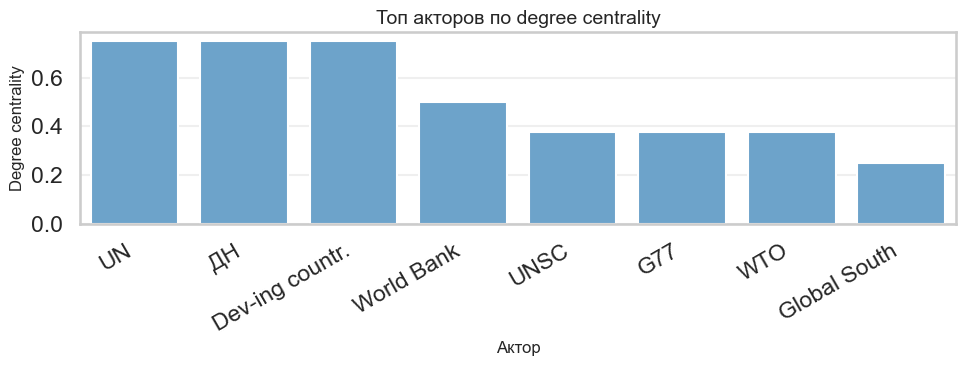

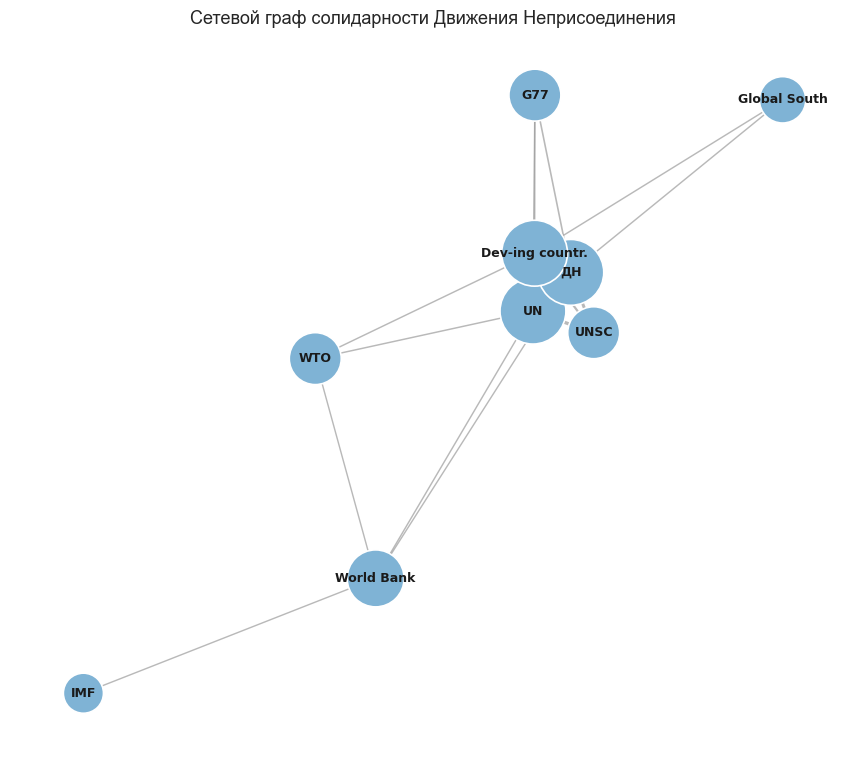

In [40]:
ACTOR_PATTERNS_EN = {
    r"\bnon[ -]aligned movement\b": "ДН",
    r"\bnam\b": "ДН",
    r"\bglobal south\b": "Global South",
    r"\bdeveloping countries\b": "Dev-ing countr.",
    r"\bg77\b": "G77",
    r"\bunited nations\b": "UN",
    r"\bsecurity council\b": "UNSC",
    r"\bwto\b": "WTO",
    r"\bimf\b": "IMF",
    r"\bworld bank\b": "World Bank",
}

SOLIDARITY_ANCHORS_EN = {
    "solidarity", "cooperation", "cooperate", "partnership", "joint",
    "consensus", "collective", "mutual", "coordination", "dialogue",
}


def sentence_split(text: str):
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", str(text)) if s.strip()]


def extract_actors_from_text(text: str):
    t = str(text).lower()
    actors = set()
    for pattern, name in ACTOR_PATTERNS_EN.items():
        if re.search(pattern, t):
            actors.add(name)
    return actors


def has_solidarity_anchor(text: str):
    t = str(text).lower()
    return any(anchor in t for anchor in SOLIDARITY_ANCHORS_EN)


def build_solidarity_graph(df_sub):
    G = nx.Graph()
    for _, row in df_sub.iterrows():
        for sent in sentence_split(row["text_clean"]):
            if not has_solidarity_anchor(sent):
                continue
            actors = sorted(extract_actors_from_text(sent))
            if len(actors) < 2:
                continue
            for i, a in enumerate(actors):
                for b in actors[i + 1:]:
                    if G.has_edge(a, b):
                        G[a][b]["weight"] += 1
                    else:
                        G.add_edge(a, b, weight=1)
    return G


G = build_solidarity_graph(df)
print("Число узлов:", G.number_of_nodes())
print("Число рёбер:", G.number_of_edges())

if G.number_of_nodes() > 0:
    deg = nx.degree_centrality(G)
    bet = nx.betweenness_centrality(G, weight="weight")
    centrality_df = (
        pd.DataFrame({
            "actor": list(deg.keys()),
            "degree_centrality": list(deg.values()),
            "betweenness_centrality": [bet[a] for a in deg.keys()],
        })
        .sort_values("degree_centrality", ascending=False)
        .reset_index(drop=True)
    )
else:
    centrality_df = pd.DataFrame(columns=["actor", "degree_centrality", "betweenness_centrality"])

print(centrality_df)

# Дополнительная визуализация центральностей
if not centrality_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(
        data=centrality_df.head(8),
        x="actor",
        y="degree_centrality",
        color="#5DA5DA",
        ax=ax,
    )
    ax.set_title("Топ акторов по degree centrality")
    ax.set_xlabel("Актор")
    ax.set_ylabel("Degree centrality")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

min_weight = 1
edges_to_keep = [(u, v) for u, v, d in G.edges(data=True) if d.get("weight", 1) >= min_weight]
H = G.edge_subgraph(edges_to_keep).copy()

if H.number_of_nodes() > 0:
    center_node = "NAM"

    if center_node in H.nodes:
        pos_init = nx.spring_layout(H, k=0.9, seed=42, weight="weight")
        pos_init[center_node] = np.array([0.0, 0.0])
        pos = nx.spring_layout(H, pos=pos_init, fixed=[center_node], k=0.9, seed=42, weight="weight")
    else:
        pos = nx.spring_layout(H, k=0.9, seed=42, weight="weight")

    weights = [H[u][v]["weight"] for u, v in H.edges()]
    max_w = max(weights) if weights else 1
    edge_widths = [1.0 + 3.5 * (w / max_w) for w in weights]

    degrees = dict(H.degree())
    max_deg = max(degrees.values()) if degrees else 1
    node_sizes = [550 + 1700 * (degrees[n] / max_deg) for n in H.nodes()]
    node_colors = ["#0B3C5D" if n == center_node else "#7FB3D5" for n in H.nodes()]

    fig, ax = plt.subplots(figsize=(9, 8))
    nx.draw_networkx_edges(H, pos, width=edge_widths, edge_color="#9E9E9E", alpha=0.72, ax=ax)
    nx.draw_networkx_nodes(
        H,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors="white",
        linewidths=1.2,
        ax=ax,
    )
    nx.draw_networkx_labels(H, pos, font_size=9, font_family="DejaVu Sans", font_weight="bold", ax=ax)

    ax.set_title("Сетевой граф солидарности Движения Неприсоединения", fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
